In [1]:
import numpy as np
import pandas as pd
    
df = pd.read_csv('spam.csv', encoding='latin-1') # specifying encoding is necessary because the data does not use UTF-8
df.head()

# Hapus kolom tambahan yang tidak diperlukan
df = df.drop(df.iloc[:, 2:], axis=1)

# Rename kolom
df.columns = ['Labels', 'Message']

print(df['Labels'].value_counts())

X = df['Message']
y = df['Labels']

Labels
ham     4825
spam     747
Name: count, dtype: int64


In [2]:
#Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 4457
Jumlah data testing: 1115


In [3]:
#CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(stop_words='english')

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("Shape X_train:", X_train_bow.shape)
print("Shape X_test:", X_test_bow.shape)

Shape X_train: (4457, 7466)
Shape X_test: (1115, 7466)


In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

mnb_bow = MultinomialNB()

# Training
mnb_bow.fit(X_train_bow, y_train)

# Prediksi training
y_pred_train_bow = mnb_bow.predict(X_train_bow)

# Prediksi testing
y_pred_test_bow = mnb_bow.predict(X_test_bow)

# Accuracy
acc_train_bow = accuracy_score(y_train, y_pred_train_bow)
acc_test_bow = accuracy_score(y_test, y_pred_test_bow)

print("Training accuracy:", acc_train_bow)
print("Testing accuracy:", acc_test_bow)

Training accuracy: 0.9946152120260264
Testing accuracy: 0.9829596412556054


In [5]:
#Evaluasi CountVectorizer
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_bow))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       954
        spam       0.98      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [6]:
#Feature TF-IDF by enabling stop_words
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape X_train:", X_train_tfidf.shape)
print("Shape X_test:", X_test_tfidf.shape)

Shape X_train: (4457, 7466)
Shape X_test: (1115, 7466)


In [7]:
mnb_tfidf = MultinomialNB()

# Training
mnb_tfidf.fit(X_train_tfidf, y_train)

# Prediksi training
y_pred_train_tfidf = mnb_tfidf.predict(X_train_tfidf)

# Prediksi testing
y_pred_test_tfidf = mnb_tfidf.predict(X_test_tfidf)

# Accuracy
acc_train_tfidf = accuracy_score(
    y_train,
    y_pred_train_tfidf
)

acc_test_tfidf = accuracy_score(
    y_test,
    y_pred_test_tfidf
)

print("Training accuracy:", acc_train_tfidf)
print("Testing accuracy:", acc_test_tfidf)

Training accuracy: 0.9842943684092439
Testing accuracy: 0.9605381165919282


In [18]:
acc_test_assignment2 = 0.9775784753363229

results = pd.DataFrame({
    'Feature': [
        'CountVectorizer (Assignment 2)',
        'CountVectorizer + Stop Words',
        'TF-IDF + Stop Words'
    ],
    'Test Accuracy': [
        acc_test_assignment2,
        acc_test_bow,
        acc_test_tfidf
    ]
})

results

,Feature,Test Accuracy
0,CountVectorizer (Assignment 2),0.977578
1,CountVectorizer + Stop Words,0.982960
2,TF-IDF + Stop Words,0.960538


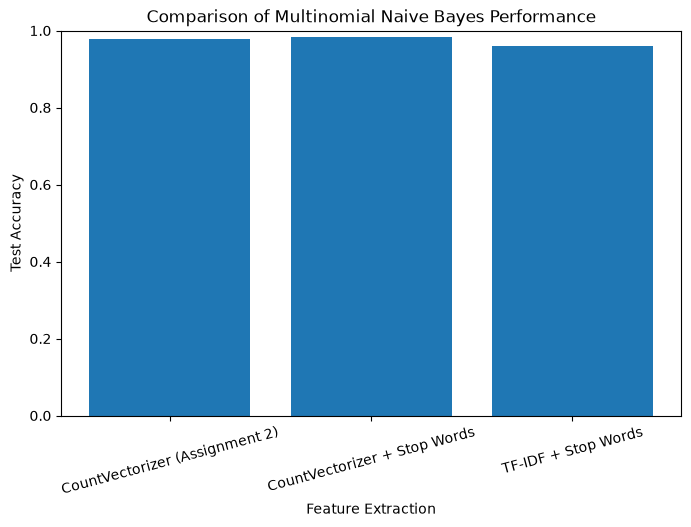

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results['Feature'],
    results['Test Accuracy']
)

plt.xlabel('Feature Extraction')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Multinomial Naive Bayes Performance')

plt.xticks(rotation=15)
plt.ylim(0, 1)

plt.show()

In [20]:
best_result = results.loc[
    results['Test Accuracy'].idxmax()
]

print("Feature terbaik:", best_result['Feature'])
print("Test accuracy:", best_result['Test Accuracy'])

Feature terbaik: CountVectorizer + Stop Words
Test accuracy: 0.9829596412556054


#### A. Multinomial Naive Bayes dengan CountVectorizer + Stop Words
Pada percobaan pertama, digunakan metode CountVectorizer dengan mengaktifkan stop_words='english' untuk menghilangkan kata-kata umum yang kurang informatif. Hasil representasi teks kemudian digunakan sebagai input untuk model Multinomial Naive Bayes. Model dievaluasi menggunakan accuracy, precision, recall, dan F1-score.

- Training accuracy: 0.9946152120260264
- Testing accuracy: 0.9829596412556054

#### B. Multinomial Naive Bayes dengan TF-IDF + Stop Words
Pada percobaan kedua, CountVectorizer digantikan dengan TF-IDF Vectorizer dengan mengaktifkan stop_words='english'. TF-IDF memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya dalam dokumen. Hasil transformasi kemudian digunakan untuk melatih model Multinomial Naive Bayes.

- Training accuracy: 0.9842943684092439
- Testing accuracy: 0.9605381165919282

| Feature / Experiment | Test Accuracy |
|---|---:|
| Assignment No. 2 – MultinomialNB | **97.75%** |
| CountVectorizer + Stop Words | **98.30%** |
| TF-IDF + Stop Words | **96.05%** |


Berdasarkan hasil eksperimen pada dataset spam.csv, tiga pendekatan dibandingkan, yaitu CountVectorizer dari Assignment No. 2, CountVectorizer dengan stop words, dan TF-IDF dengan stop words. Hasil evaluasi menunjukkan bahwa CountVectorize + Stop Words menghasilkan testing accuracy paling tinggi sebesar 98.30. Oleh karena itu, pendekatan tersebut dapat dianggap sebagai feature extraction yang paling optimal untuk digunakan pada klasifikasi spam menggunakan Multinomial Naive Bayes pada dataset ini.